<a href="https://colab.research.google.com/github/Rawan806/2025_GP_18/blob/main/Wadiah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import requests
from PIL import Image
from io import BytesIO

df = pd.read_csv("wadiah_items_clean.csv")

In [3]:
def load_image(url):
    response = requests.get(url, timeout=10)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    img = img.resize((224, 224))
    return img

https://firebasestorage.googleapis.com/v0/b/wadiah-6225a.firebasestorage.app/o/lost_items%2F1772594261741.jpg?alt=media&token=aa487325-5e57-460d-bfaf-bb9865d8eca4



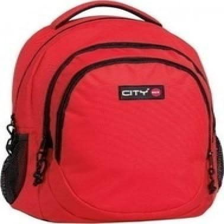

In [4]:
url = df["imageUrl"].iloc[0]
print(url)

img = load_image(url)
img

In [5]:
valid_items = []
failed_items = []

for i, row in df.iterrows():
    url = row["imageUrl"]
    doc_id = row["docId"]

    try:
        img = load_image(url)
        valid_items.append({
            "docId": doc_id,
            "imageUrl": url,
            "collection": row.get("collection", ""),
            "type": row.get("type", ""),
            "color": row.get("color", ""),
            "status": row.get("status", ""),
            "img": img
        })
        print(f"Loaded: {doc_id}")
    except Exception as e:
        failed_items.append({
            "docId": doc_id,
            "imageUrl": url,
            "error": str(e)
        })
        print(f"Failed: {doc_id} -> {e}")

Loaded: 1772594265651
Loaded: 1764835820
Loaded: 1765258137163
Loaded: 1764900956742
Loaded: 1764838623153
Loaded: 1764835890
Loaded: 1764835779
Loaded: 1764835800
Loaded: 1764835818
Loaded: 1773094714518
Loaded: 1773098118177
Loaded: 1773185775781
Loaded: 1773098173320
Loaded: 1773185578174
Loaded: 1773202054081
Loaded: 1773185473252
Loaded: 1773185836068
Loaded: 1773094539720
Loaded: 1773185718137
Loaded: 1772594265651
Loaded: 1773098306624
Loaded: 1773098037355
Loaded: 1773098248471
Loaded: 1773098491169
Loaded: 1773185323710
Loaded: 1773095620463
Loaded: 1773094475646
Loaded: 1773097984370
Loaded: 1773095699155
Loaded: 1773202394434
Loaded: 1773186110935
Loaded: 1773098374948
Loaded: 1773202165503
Loaded: 1773185912862
Loaded: 1773097882917
Loaded: 1773185417545
Loaded: 1773095120715
Loaded: 1773095537298
Loaded: 1773095291757
Loaded: 1773095388090
Loaded: 1773095213211
Loaded: 1773201958298
Loaded: 1773095479968
Loaded: 1773186063931
Loaded: 1773097938110
Loaded: 1773185664866
Loa

In [6]:
print("Valid items:", len(valid_items))
print("Failed items:", len(failed_items))

Valid items: 49
Failed items: 0


# Extracting features

In [7]:
import numpy as np
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

model = MobileNetV3Small(weights="imagenet", include_top=False, pooling="avg")

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
def get_embedding(pil_img):
    arr = img_to_array(pil_img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    emb = model.predict(arr, verbose=0)[0]
    return emb

In [9]:
embeddings = []
meta = []

for item in valid_items:
    emb = get_embedding(item["img"])
    embeddings.append(emb)

    meta.append({
        "docId": item["docId"],
        "imageUrl": item["imageUrl"],
        "collection": item["collection"],
        "type": item["type"],
        "color": item["color"],
        "status": item["status"]
    })

In [10]:
embeddings = np.array(embeddings)
print("Embeddings shape:", embeddings.shape)

Embeddings shape: (49, 576)


## L2 normalization

In [11]:
from numpy.linalg import norm

embeddings = embeddings / np.clip(norm(embeddings, axis=1, keepdims=True), 1e-12, None)

In [12]:
import json

np.save("embeddings.npy", embeddings)

with open("meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

In [13]:
from datetime import datetime, UTC

index_info = {
    "model_name": "MobileNetV3Small",
    "img_size": 224,
    "preprocessing": "mobilenet_v3 preprocess_input + resize(224,224)",
    "num_items": len(meta),
    "embedding_dim": int(embeddings.shape[1]),
    "built_at": datetime.now(UTC).isoformat()
}

with open("index_info.json", "w", encoding="utf-8") as f:
    json.dump(index_info, f, ensure_ascii=False, indent=2)

## searching

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def search_similar(query_img, top_k=5):
    query_emb = get_embedding(query_img)
    query_emb = query_emb / np.clip(np.linalg.norm(query_emb), 1e-12, None)

    sims = cosine_similarity([query_emb], embeddings)[0]
    top_indices = np.argsort(sims)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "docId": meta[idx]["docId"],
            "imageUrl": meta[idx]["imageUrl"],
            "collection": meta[idx]["collection"],
            "type": meta[idx]["type"],
            "color": meta[idx]["color"],
            "status": meta[idx]["status"],
            "similarity": float(sims[idx])
        })

    return results

In [15]:
test_img = valid_items[0]["img"]
results = search_similar(test_img, top_k=5)
results

[{'docId': 1772594265651,
  'imageUrl': 'https://firebasestorage.googleapis.com/v0/b/wadiah-6225a.firebasestorage.app/o/lost_items%2F1772594261741.jpg?alt=media&token=aa487325-5e57-460d-bfaf-bb9865d8eca4',
  'collection': 'lost',
  'type': 'حقيبة',
  'color': 'أحمر',
  'status': 'قيد المراجعة',
  'similarity': 1.000000238418579},
 {'docId': 1772594265651,
  'imageUrl': 'https://firebasestorage.googleapis.com/v0/b/wadiah-6225a.firebasestorage.app/o/lost_items%2F1772594261741.jpg?alt=media&token=aa487325-5e57-460d-bfaf-bb9865d8eca4\n',
  'collection': 'lost',
  'type': 'حقيبة',
  'color': 'أحمر',
  'status': 'قيد المراجعة',
  'similarity': 1.000000238418579},
 {'docId': 1773095291757,
  'imageUrl': 'https://firebasestorage.googleapis.com/v0/b/wadiah-6225a.firebasestorage.app/o/lost_items%2F1773095288165.jpg?alt=media&token=477f0d37-2347-4f61-9b7d-4abbb81effa2',
  'collection': 'lost',
  'type': 'حقيبة ظهر',
  'color': 'بنفسجي',
  'status': 'قيد المراجعة',
  'similarity': 0.84998756647109

In [16]:
with open("failed_items.json", "w", encoding="utf-8") as f:
    json.dump(failed_items, f, ensure_ascii=False, indent=2)